In [3]:
import pandas as pd

df = pd.read_excel(r"C:\Users\alaja\Downloads\retail_sales_analysis.xlsx")

df.head()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Segment,Region,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Discount,Sales,Profit,Shipping_Cost,profit_margin,Discount_band,shipping as % of sales
0,ORD-14680,2022-01-01,2022-01-05,CUST-1711,Frank Allen,Consumer,West,Technology,Phones,OnePlus 11,3,711.38,0.00,2134.14,409.51,10.06,0.191885,0%,0.004714
1,ORD-11151,2022-01-01,2022-01-06,CUST-1713,Quinn Garcia,Corporate,South,Technology,Accessories,Webcam 1080p,3,61.26,0.00,183.78,58.10,13.43,0.316139,0%,0.073077
2,ORD-12159,2022-01-01,2022-01-07,CUST-1346,Nathan White,Corporate,East,Technology,Monitors,"LG 27"" 4K Monitor",3,409.35,0.00,1228.05,211.41,19.74,0.172151,0%,0.016074
3,ORD-13554,2022-01-01,2022-01-08,CUST-1289,Meera Brown,Consumer,West,Technology,Accessories,Logitech MX Master 3,2,99.02,0.05,188.14,52.08,10.89,0.276815,1-10%,0.057882
4,ORD-10548,2022-01-01,2022-01-09,CUST-1307,Bob Chen,Consumer,South,Technology,Accessories,Webcam 1080p,1,57.23,0.05,54.37,16.43,21.94,0.302189,1-10%,0.403531


In [4]:
print(df.shape)

(10500, 19)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order_ID                10500 non-null  object        
 1   Order_Date              10500 non-null  datetime64[ns]
 2   Ship_Date               10500 non-null  datetime64[ns]
 3   Customer_ID             10500 non-null  object        
 4   Customer_Name           10500 non-null  object        
 5   Segment                 10500 non-null  object        
 6   Region                  10500 non-null  object        
 7   Category                10500 non-null  object        
 8   Sub_Category            10500 non-null  object        
 9   Product_Name            10500 non-null  object        
 10  Quantity                10500 non-null  int64         
 11  Unit_Price              10500 non-null  float64       
 12  Discount                10500 non-null  float6

In [6]:
df.isnull().sum()

Order_ID                  0
Order_Date                0
Ship_Date                 0
Customer_ID               0
Customer_Name             0
Segment                   0
Region                    0
Category                  0
Sub_Category              0
Product_Name              0
Quantity                  0
Unit_Price                0
Discount                  0
Sales                     0
Profit                    0
Shipping_Cost             0
profit_margin             0
Discount_band             0
shipping as % of sales    0
dtype: int64

In [7]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()

print("Total Sales :", round(total_sales,2))
print("Total Profit :", round(total_profit,2))
print("Total Orders :", total_orders)

Total Sales : 6705515.46
Total Profit : 1385339.07
Total Orders : 10500


In [8]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       1828245.82
South      1753873.15
East       1607652.77
Central    1515743.72
Name: Sales, dtype: float64


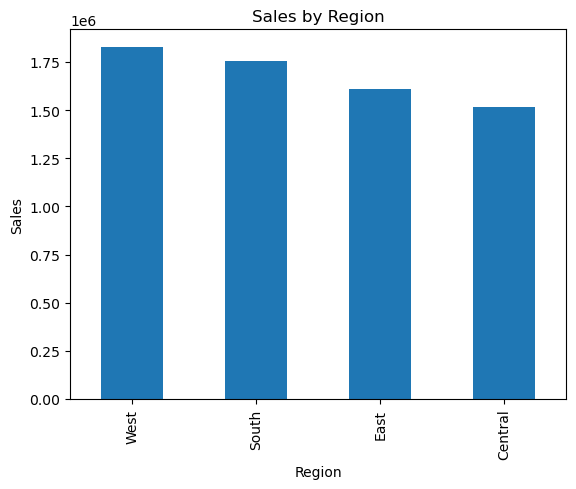

In [9]:
import matplotlib.pyplot as plt

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.ylabel('Sales')
plt.show()

In [10]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         4883190.43
Furniture          1691442.30
Office Supplies     130882.73
Name: Sales, dtype: float64


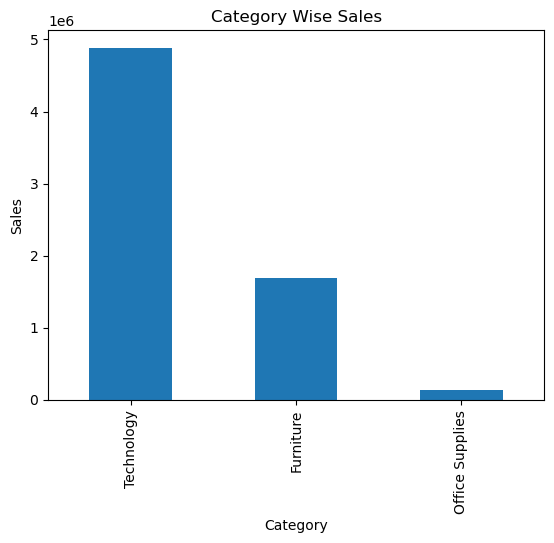

In [11]:
category_sales.plot(kind='bar')

plt.title('Category Wise Sales')
plt.ylabel('Sales')
plt.show()

In [12]:
top_products = (
    df.groupby('Product_Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product_Name
MacBook Air M2             846065.52
iPhone 15 Pro              641882.34
Dell Inspiron 15           531833.78
Lenovo ThinkPad E15        430524.91
HP Pavilion 15             416288.02
OnePlus 11                 412691.06
Samsung Galaxy S23         356153.17
Google Pixel 8             343738.63
L-Shaped Corner Desk       237304.32
Leather Executive Chair    223158.47
Name: Sales, dtype: float64


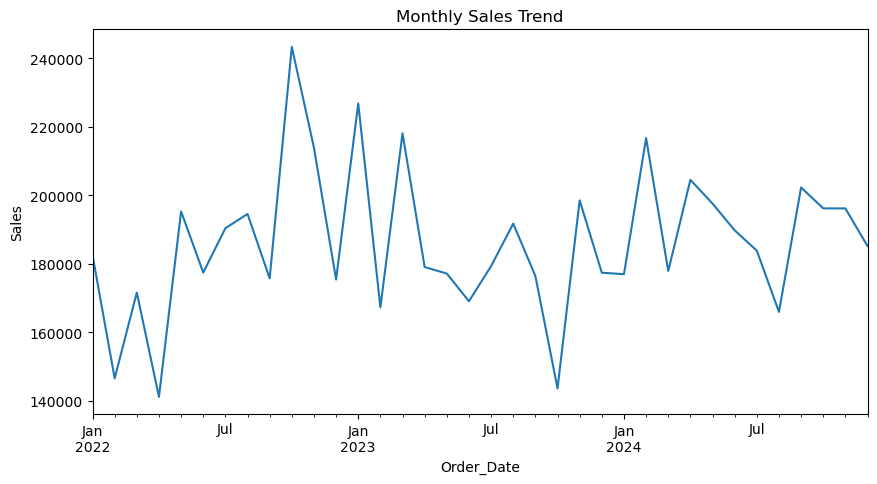

In [13]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

monthly_sales = (
    df.groupby(df['Order_Date'].dt.to_period('M'))['Sales']
      .sum()
)

monthly_sales.plot(figsize=(10,5))

plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()

In [14]:
region_analysis = df.groupby('Region')[['Sales','Profit']].sum()

print(region_analysis)

              Sales     Profit
Region                        
Central  1515743.72  311488.21
East     1607652.77  334558.51
South    1753873.15  361862.73
West     1828245.82  377429.62


In [15]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.098449
Profit,-0.098449,1.000000


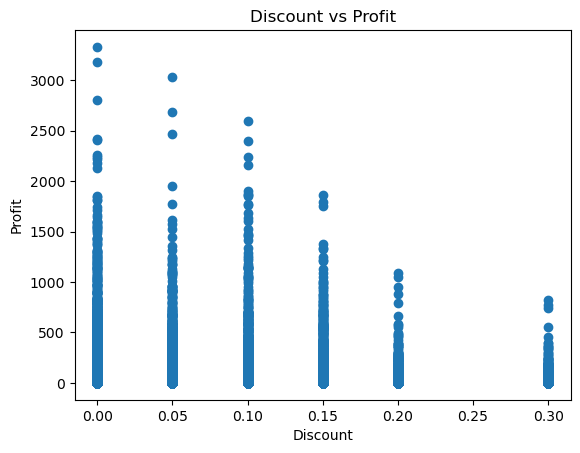

In [16]:
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()

In [17]:
top_customers = (
    df.groupby('Customer_Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

Customer_Name
Vikram Kim        60048.14
Kavya Hall        58028.80
Pooja Allen       40969.28
Alice Martinez    40529.49
Victor Allen      40355.60
Anjali Allen      40083.51
Frank Scott       35185.93
Henry Jackson     34087.04
Paul Lee          32839.49
Meera Brown       32582.11
Name: Sales, dtype: float64


In [18]:
category_analysis = (
    df.groupby('Category')[['Sales','Profit']]
      .sum()
      .sort_values('Sales', ascending=False)
)

print(category_analysis)

                      Sales      Profit
Category                               
Technology       4883190.43  1003873.59
Furniture        1691442.30   354108.48
Office Supplies   130882.73    27357.00


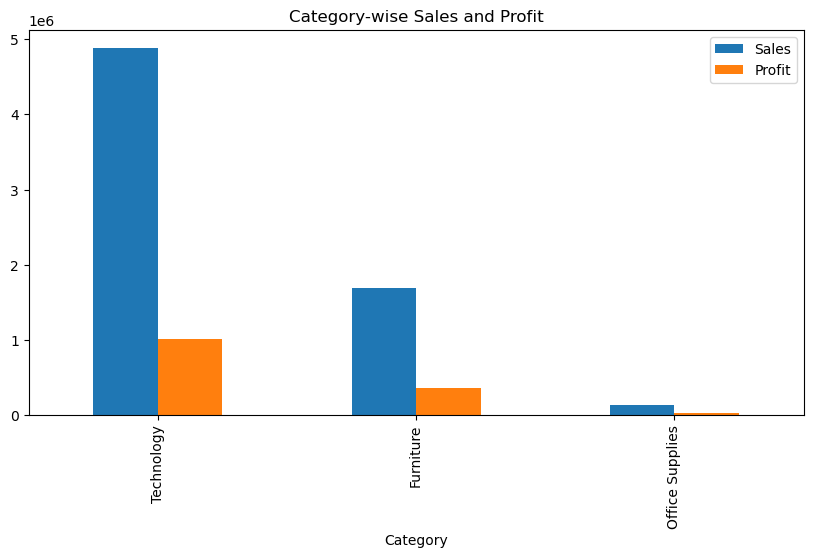

In [19]:
category_analysis.plot(kind='bar', figsize=(10,5))
plt.title('Category-wise Sales and Profit')
plt.show()

In [20]:
print("Key Insights")
print("1. West region achieved highest sales and profit.")
print("2. Central region recorded lowest performance.")
print("3. Discounts show a negative correlation with profit.")
print("4. Top-performing products contribute significantly to revenue.")

Key Insights
1. West region achieved highest sales and profit.
2. Central region recorded lowest performance.
3. Discounts show a negative correlation with profit.
4. Top-performing products contribute significantly to revenue.
